In [1]:
import pandas as pd
import numpy as np
import blinksear as ear
import blinksdistance as distance
import blinkscolors as colors
import json
import matplotlib.pyplot as plt
from pathlib import Path

from blinksear import isBlinkByEar
from blinksear import isBlinkByEar1
from blinksear import isBlinkByEar2
from blinksdistance import BlinkDistance
from blinkscolors import Colors
from blinkscorrelation import Correlation

In [2]:
def generate_webgazer_dataframe(df):
    df_webgazer = df[~df["webgazer_data"].isna()]
    dfs = []
    for row in range(len(df_webgazer)):
        data_list = json.loads(df_webgazer["webgazer_data"].iloc[row])
        df_tmp = pd.DataFrame(data_list)
        df_tmp["trial"] = row + 1
        dfs.append(df_tmp)
    return pd.concat(dfs)

In [3]:
# This can load all data but is not storing df_webgazer in any place
files = Path("./data").glob("*.csv")
dfs = []
i = 0
for file in files:
    if "blink" in str(file):
        print(file)
        df = pd.read_csv(file)
        df_tmp = generate_webgazer_dataframe(df)
        print(len(df_tmp))
        df_tmp["experiment"] = i
        df_tmp["file_name"] = str(file)
        i+=1
        dfs.append(df_tmp)

df_webgazer = pd.concat(dfs)
print(len(df_webgazer))

data/blink-experiment-9.csv
2296
data/blink-experiment-15.csv
1986
data/blink-experiment-8.csv
1589
data/blink-experiment-12.csv
1900
data/blink-experiment-13.csv
1383
data/blink-experiment-11.csv
1407
data/blink-experiment-10.csv
1135
data/blink-experiment-6.csv
1432
data/blink-experiment-expose-points_1 (1).csv
1426
data/blink-experiment-7.csv
1923
data/blink-experiment-5.csv
1272
data/blink-experiment-expose-points_3.csv
2132
data/blink-experiment-expose-points_2.csv
1301
data/blink-experiment-expose-points_4.csv
1519
22701


In [4]:
blinkDistance = distance.BlinkDistance()
blinkColors = Colors()
blinkCorrelations = Correlation()


df_webgazer["isBlinkByEar"] = df_webgazer["importantKeypoints"].map(
    lambda x: isBlinkByEar(
        x["rightEyeTopArc"],
        x["rightEyeBottomArc"],
        x["leftEyeTopArc"],
        x["leftEyeBottomArc"],
    )
)
df_webgazer["isBlinkByDistance"] = df_webgazer["importantKeypoints"].map(
    lambda x: blinkDistance.isBlinkByDistance(
        x["rightEyeTopArc"],
        x["rightEyeBottomArc"],
        x["leftEyeTopArc"],
        x["leftEyeBottomArc"],
    )
)
df_webgazer["isBlinkColors"] = df_webgazer.apply(
    lambda row: blinkColors.isBlinkByColors(
        list(row["leftEye"]["data"].values()), list(row["rightEye"]["data"].values())
    ),
    axis=1,
)


df_webgazer["isBlinkByCorrelation"] = df_webgazer.apply(
    lambda row: blinkCorrelations.isBlinkByCorrelation(
        list(row["leftEye"]["data"].values()), list(row["rightEye"]["data"].values())
    ),
    axis=1,
)


# df_webgazer['isBlinkByEar'] = df_webgazer['importantKeypoints'].map(lambda x: isBlinkByEar(x['rightEyeTopArc'], x['rightEyeBottomArc'], x['leftEyeTopArc'], x['leftEyeBottomArc']))

df_webgazer

,x,y,t,importantKeypoints,leftEye,rightEye,dz,trial,experiment,file_name,isBlinkByEar,isBlinkByDistance,isBlinkColors,isBlinkByCorrelation
0,0,0,62,"{'noseX': 288.29, 'noseY': 313.05, 'topY': 190...","{'data': {'0': 84, '1': 62, '2': 42, '3': 255,...","{'data': {'0': 144, '1': 105, '2': 82, '3': 25...",51.57,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
1,0,0,81,"{'noseX': 289.14, 'noseY': 313.56, 'topY': 190...","{'data': {'0': 44, '1': 30, '2': 15, '3': 255,...","{'data': {'0': 66, '1': 41, '2': 27, '3': 255,...",52.57,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
2,0,0,106,"{'noseX': 289.29, 'noseY': 313.86, 'topY': 190...","{'data': {'0': 46, '1': 31, '2': 15, '3': 255,...","{'data': {'0': 66, '1': 43, '2': 26, '3': 255,...",53.01,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
3,0,0,142,"{'noseX': 288.98, 'noseY': 313.11, 'topY': 190...","{'data': {'0': 46, '1': 31, '2': 15, '3': 255,...","{'data': {'0': 64, '1': 42, '2': 25, '3': 255,...",50.86,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
4,0,0,175,"{'noseX': 289.17, 'noseY': 313.61, 'topY': 190...","{'data': {'0': 48, '1': 32, '2': 16, '3': 255,...","{'data': {'0': 67, '1': 42, '2': 27, '3': 255,...",52.18,1,0,data/blink-experiment-9.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,0,0,16670,"{'noseX': 332.29, 'noseY': 308.27, 'topY': 164...","{'data': {'0': 124, '1': 97, '2': 52, '3': 255...","{'data': {'0': 116, '1': 73, '2': 27, '3': 255...",41.95,4,13,data/blink-experiment-expose-points_4.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
491,0,0,16701,"{'noseX': 331.28, 'noseY': 308.62, 'topY': 165...","{'data': {'0': 128, '1': 100, '2': 58, '3': 25...","{'data': {'0': 121, '1': 77, '2': 32, '3': 255...",39.36,4,13,data/blink-experiment-expose-points_4.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
492,0,0,16732,"{'noseX': 331.85, 'noseY': 308.55, 'topY': 165...","{'data': {'0': 83, '1': 58, '2': 14, '3': 255,...","{'data': {'0': 112, '1': 69, '2': 26, '3': 255...",40.61,4,13,data/blink-experiment-expose-points_4.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."
493,0,0,16772,"{'noseX': 331.27, 'noseY': 309.03, 'topY': 165...","{'data': {'0': 127, '1': 101, '2': 54, '3': 25...","{'data': {'0': 112, '1': 69, '2': 26, '3': 255...",39.11,4,13,data/blink-experiment-expose-points_4.csv,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal..."


In [ ]:
list_blink_ear = df_webgazer["importantKeypoints"].map(
    lambda x: isBlinkByEar(
        x["rightEyeTopArc"],
        x["rightEyeBottomArc"],
        x["leftEyeTopArc"],
        x["leftEyeBottomArc"],
    )
)

list_blink_ear.map(lambda x: len(x)).head()

In [5]:
df_webgazer["isBlinkByEar"].apply(lambda x: len(x)).head()

0    18
1    18
2    18
3    18
4    18
Name: isBlinkByEar, dtype: int64

In [ ]:
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[1]==True)+1)
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[2]==True)+2)
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[3]==True)+3)
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[4]==True)+4)
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[5]==True)+5)
df_webgazer["Blink_sample6"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[6]==True)+6)
df_webgazer["Blink_sample7"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[7]==True)+7)

In [ ]:
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[1]==True))
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[2]==True))
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[3]==True))
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[4]==True))
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[5]==True))
df_webgazer["Blink_sample6"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[6]==True))
df_webgazer["Blink_sample7"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[7]==True))
df_webgazer["Blink_sample8"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[8]==True))
df_webgazer["Blink_sample9"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[9]==True))
df_webgazer["Blink_sample10"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[10]==True))
df_webgazer["Blink_sample11"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[12]==True))
df_webgazer["Blink_sample12"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[13]==True))
df_webgazer["Blink_sample13"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[13]==True))
df_webgazer["Blink_sample14"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[14]==True))
df_webgazer["Blink_sample15"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[15]==True))
df_webgazer["Blink_sample16"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[16]==True))
df_webgazer["Blink_sample17"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[17]==True))


In [ ]:
df_webgazer.head()

In [ ]:
df_webgazer['Blink_sample3'][df_webgazer['Blink_sample3'].diff()>0].shape

In [ ]:
df_webgazer["Blink_sample0_diff"] = (df_webgazer['Blink_sample'].shift(1)+1 == df_webgazer['Blink_sample'])
df_webgazer["Blink_sample1_diff"] = (df_webgazer['Blink_sample1'].shift(1)+1 == df_webgazer['Blink_sample1'])
df_webgazer["Blink_sample2_diff"] = (df_webgazer['Blink_sample2'].shift(1)+1 == df_webgazer['Blink_sample2'])
df_webgazer["Blink_sample3_diff"] = (df_webgazer['Blink_sample3'].shift(1)+1 == df_webgazer['Blink_sample3'])
df_webgazer["Blink_sample4_diff"] = (df_webgazer['Blink_sample4'].shift(1)+1 == df_webgazer['Blink_sample4'])
df_webgazer["Blink_sample5_diff"] = (df_webgazer['Blink_sample5'].shift(1)+1 == df_webgazer['Blink_sample5'])
df_webgazer["Blink_sample6_diff"] = (df_webgazer['Blink_sample6'].shift(1)+1 == df_webgazer['Blink_sample6'])
df_webgazer["Blink_sample7_diff"] = (df_webgazer['Blink_sample7'].shift(1)+1 == df_webgazer['Blink_sample7'])
df_webgazer["Blink_sample8_diff"] = (df_webgazer['Blink_sample8'].shift(1)+1 == df_webgazer['Blink_sample8'])
df_webgazer["Blink_sample9_diff"] = (df_webgazer['Blink_sample9'].shift(1)+1 == df_webgazer['Blink_sample9'])
df_webgazer["Blink_sample10_diff"] = (df_webgazer['Blink_sample10'].shift(1)+1 == df_webgazer['Blink_sample10'])
df_webgazer["Blink_sample11_diff"] = (df_webgazer['Blink_sample11'].shift(1)+1 == df_webgazer['Blink_sample11'])
df_webgazer["Blink_sample12_diff"] = (df_webgazer['Blink_sample12'].shift(1)+1 == df_webgazer['Blink_sample12'])
df_webgazer["Blink_sample13_diff"] = (df_webgazer['Blink_sample13'].shift(1)+1 == df_webgazer['Blink_sample13'])
df_webgazer["Blink_sample14_diff"] = (df_webgazer['Blink_sample14'].shift(1)+1 == df_webgazer['Blink_sample14'])
df_webgazer["Blink_sample15_diff"] = (df_webgazer['Blink_sample15'].shift(1)+1 == df_webgazer['Blink_sample15'])
df_webgazer["Blink_sample16_diff"] = (df_webgazer['Blink_sample16'].shift(1)+1 == df_webgazer['Blink_sample16'])
df_webgazer["Blink_sample17_diff"] = (df_webgazer['Blink_sample17'].shift(1)+1 == df_webgazer['Blink_sample17'])

results = []
for x in range(0,18):
    tmp_result = df_webgazer.groupby(['trial', 'file_name'])['Blink_sample' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

cleaned_results = [results[0]] + [df.drop(columns=['trial', 'file_name']) for df in results[1:]]
result = pd.concat(cleaned_results, axis=1)
result

In [ ]:
threshold_columns = [col for col in result.columns if col not in ['trial', 'file_name']]
result['should_be'] = result['trial'].apply(lambda x: 2 if x == 3 else 10)
result[result['trial']==3]


In [ ]:
results = []
for x in range(0,8):
    tmp_result = df_webgazer[df_webgazer['trial']==3].groupby('file_name')['Blink_sample' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

result = pd.concat(results, axis=1, join='inner')
result

In [16]:
df_webgazer

,x,y,t,importantKeypoints,leftEye,rightEye,dz,trial,experiment,file_name,...,isBlinkColors,isBlinkByCorrelation,Blink_sample_ear,Blink_sample_ear_diff,Blink_sample_dist,Blink_sample_dist_diff,Blink_sample_col,Blink_sample_col_diff,Blink_sample_corr,Blink_sample_corr_diff
0,0,0,62,"{'noseX': 288.29, 'noseY': 313.05, 'topY': 190...","{'data': {'0': 84, '1': 62, '2': 42, '3': 255,...","{'data': {'0': 144, '1': 105, '2': 82, '3': 25...",51.57,1,0,data/blink-experiment-9.csv,...,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,False,0,False,0,False,0,False
1,0,0,81,"{'noseX': 289.14, 'noseY': 313.56, 'topY': 190...","{'data': {'0': 44, '1': 30, '2': 15, '3': 255,...","{'data': {'0': 66, '1': 41, '2': 27, '3': 255,...",52.57,1,0,data/blink-experiment-9.csv,...,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,False,0,False,0,False,0,False
2,0,0,106,"{'noseX': 289.29, 'noseY': 313.86, 'topY': 190...","{'data': {'0': 46, '1': 31, '2': 15, '3': 255,...","{'data': {'0': 66, '1': 43, '2': 26, '3': 255,...",53.01,1,0,data/blink-experiment-9.csv,...,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,False,0,False,0,False,0,False
3,0,0,142,"{'noseX': 288.98, 'noseY': 313.11, 'topY': 190...","{'data': {'0': 46, '1': 31, '2': 15, '3': 255,...","{'data': {'0': 64, '1': 42, '2': 25, '3': 255,...",50.86,1,0,data/blink-experiment-9.csv,...,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,False,0,False,0,False,0,False
4,0,0,175,"{'noseX': 289.17, 'noseY': 313.61, 'topY': 190...","{'data': {'0': 48, '1': 32, '2': 16, '3': 255,...","{'data': {'0': 67, '1': 42, '2': 27, '3': 255,...",52.18,1,0,data/blink-experiment-9.csv,...,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,False,0,False,0,False,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,0,0,16670,"{'noseX': 332.29, 'noseY': 308.27, 'topY': 164...","{'data': {'0': 124, '1': 97, '2': 52, '3': 255...","{'data': {'0': 116, '1': 73, '2': 27, '3': 255...",41.95,4,13,data/blink-experiment-expose-points_4.csv,...,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,False,0,False,0,False,0,False
491,0,0,16701,"{'noseX': 331.28, 'noseY': 308.62, 'topY': 165...","{'data': {'0': 128, '1': 100, '2': 58, '3': 25...","{'data': {'0': 121, '1': 77, '2': 32, '3': 255...",39.36,4,13,data/blink-experiment-expose-points_4.csv,...,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,False,0,False,0,False,0,False
492,0,0,16732,"{'noseX': 331.85, 'noseY': 308.55, 'topY': 165...","{'data': {'0': 83, '1': 58, '2': 14, '3': 255,...","{'data': {'0': 112, '1': 69, '2': 26, '3': 255...",40.61,4,13,data/blink-experiment-expose-points_4.csv,...,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,False,0,False,0,False,0,False
493,0,0,16772,"{'noseX': 331.27, 'noseY': 309.03, 'topY': 165...","{'data': {'0': 127, '1': 101, '2': 54, '3': 25...","{'data': {'0': 112, '1': 69, '2': 26, '3': 255...",39.11,4,13,data/blink-experiment-expose-points_4.csv,...,"[False, False, False, False, False, False, Fal...","[False, False, False, False, False, False, Fal...",0,False,0,False,0,False,0,False


In [17]:
 #resultados por participante blink ear
df_webgazer["Blink_sample_ear"] = df_webgazer["isBlinkByEar"].apply(lambda x: int(x[10]==True))
df_webgazer["Blink_sample_ear_diff"] = (df_webgazer['Blink_sample_ear'].shift(1)+1 == df_webgazer['Blink_sample_ear'])


result_per_participant_ear = df_webgazer.groupby(['file_name', 'trial'])['Blink_sample_ear_diff'].sum().reset_index()
result_per_participant_ear


,file_name,trial,Blink_sample_ear_diff
0,data/blink-experiment-10.csv,1,11
1,data/blink-experiment-10.csv,2,10
2,data/blink-experiment-10.csv,3,2
3,data/blink-experiment-10.csv,4,11
4,data/blink-experiment-10.csv,5,11
...,...,...,...
71,data/blink-experiment-expose-points_3.csv,4,28
72,data/blink-experiment-expose-points_4.csv,1,13
73,data/blink-experiment-expose-points_4.csv,2,11
74,data/blink-experiment-expose-points_4.csv,3,9


In [18]:
 #resultados por participante blink distance
df_webgazer["Blink_sample_dist"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[6]==True))
df_webgazer["Blink_sample_dist_diff"] = (df_webgazer['Blink_sample_dist'].shift(1)+1 == df_webgazer['Blink_sample_dist'])


result_per_participant_dist = df_webgazer.groupby(['file_name', 'trial'])['Blink_sample_dist_diff'].sum().reset_index()
result_per_participant_dist

,file_name,trial,Blink_sample_dist_diff
0,data/blink-experiment-10.csv,1,12
1,data/blink-experiment-10.csv,2,10
2,data/blink-experiment-10.csv,3,2
3,data/blink-experiment-10.csv,4,11
4,data/blink-experiment-10.csv,5,11
...,...,...,...
71,data/blink-experiment-expose-points_3.csv,4,29
72,data/blink-experiment-expose-points_4.csv,1,13
73,data/blink-experiment-expose-points_4.csv,2,10
74,data/blink-experiment-expose-points_4.csv,3,9


In [19]:
 #resultados por participante blink color
df_webgazer["Blink_sample_col"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[8]==True))
df_webgazer["Blink_sample_col_diff"] = (df_webgazer['Blink_sample_col'].shift(1)+1 == df_webgazer['Blink_sample_col'])


result_per_participant_col = df_webgazer.groupby(['file_name', 'trial'])['Blink_sample_col_diff'].sum().reset_index()
result_per_participant_col

,file_name,trial,Blink_sample_col_diff
0,data/blink-experiment-10.csv,1,9
1,data/blink-experiment-10.csv,2,13
2,data/blink-experiment-10.csv,3,6
3,data/blink-experiment-10.csv,4,15
4,data/blink-experiment-10.csv,5,18
...,...,...,...
71,data/blink-experiment-expose-points_3.csv,4,7
72,data/blink-experiment-expose-points_4.csv,1,9
73,data/blink-experiment-expose-points_4.csv,2,15
74,data/blink-experiment-expose-points_4.csv,3,6


In [20]:
 #resultados por participante blink corr
df_webgazer["Blink_sample_corr"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[3]==True))
df_webgazer["Blink_sample_corr_diff"] = (df_webgazer['Blink_sample_corr'].shift(1)+1 == df_webgazer['Blink_sample_corr'])


result_per_participant_corr = df_webgazer.groupby(['file_name', 'trial'])['Blink_sample_corr_diff'].sum().reset_index()
result_per_participant_corr

,file_name,trial,Blink_sample_corr_diff
0,data/blink-experiment-10.csv,1,5
1,data/blink-experiment-10.csv,2,1
2,data/blink-experiment-10.csv,3,1
3,data/blink-experiment-10.csv,4,11
4,data/blink-experiment-10.csv,5,11
...,...,...,...
71,data/blink-experiment-expose-points_3.csv,4,8
72,data/blink-experiment-expose-points_4.csv,1,11
73,data/blink-experiment-expose-points_4.csv,2,16
74,data/blink-experiment-expose-points_4.csv,3,5


In [28]:
result_per_participant_ear['error'] = np.where(
    result_per_participant_ear['trial'] == 3,
    np.abs(result_per_participant_ear['Blink_sample_ear_diff'] - 2),
    np.abs(result_per_participant_ear['Blink_sample_ear_diff'] - 10)
)
result_per_participant_ear = result_per_participant_ear.groupby('file_name')['error'].mean().reset_index()

result_per_participant_ear

,file_name,error
0,data/blink-experiment-10.csv,1.166667
1,data/blink-experiment-11.csv,0.333333
2,data/blink-experiment-12.csv,10.166667
3,data/blink-experiment-13.csv,0.166667
4,data/blink-experiment-15.csv,5.000000
5,data/blink-experiment-5.csv,0.666667
6,data/blink-experiment-6.csv,1.166667
7,data/blink-experiment-7.csv,0.333333
8,data/blink-experiment-8.csv,0.166667
9,data/blink-experiment-9.csv,0.000000


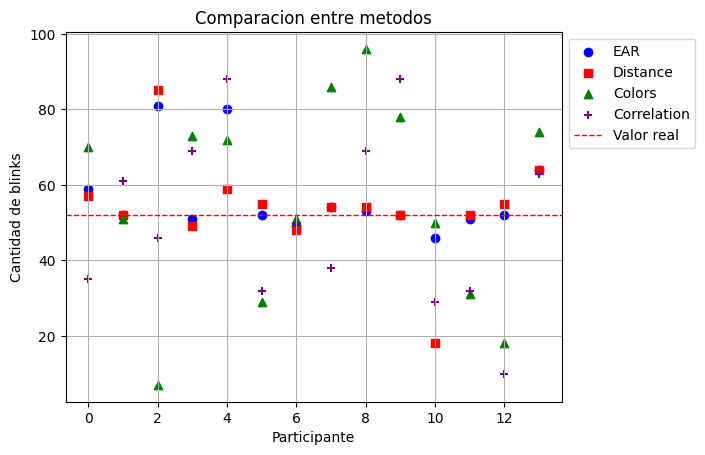

In [13]:
result_per_participant_ear
result_per_participant_dist
result_per_participant_col
result_per_participant_corr


plt.scatter(list(range(14)), result_per_participant_ear['Blink_sample_ear_diff'], marker='o', color='blue', label='EAR')  # círculo
plt.scatter(list(range(14)), result_per_participant_dist['Blink_sample_dist_diff'], marker='s', color='red', label='Distance')   # cuadrado
plt.scatter(list(range(14)), result_per_participant_col['Blink_sample_col_diff'], marker='^', color='green', label='Colors') # triángulo
plt.scatter(list(range(14)), result_per_participant_corr['Blink_sample_corr_diff'], marker='+', color='purple', label='Correlation') # cruz

plt.axhline(y=52, color="red", linestyle="--", lw=1, label= "Valor real")

plt.xlabel('Participante')
plt.ylabel('Cantidad de blinks')
plt.title('Comparacion entre metodos')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)  # Leyenda fuera del gráfico
plt.grid(True)  # Activar la cuadrícula

# Mostrar
plt.show()


In [ ]:
result_per_participant_ear
result_per_participant_dist
result_per_participant_col
result_per_participant_corr

result_per_participant_ear


result_per_participant_ear['metodo'] = 'ear'
result_per_participant_ear['Blink_sample_diff'] = result_per_participant_ear['Blink_sample_ear_diff']
result_per_participant_dist['metodo'] = 'dist'
result_per_participant_dist['Blink_sample_diff'] = result_per_participant_dist['Blink_sample_dist_diff']
result_per_participant_col['metodo'] = 'col'
result_per_participant_col['Blink_sample_diff'] = result_per_participant_col['Blink_sample_col_diff']
result_per_participant_corr['metodo'] = 'corr'
result_per_participant_corr['Blink_sample_diff'] = result_per_participant_corr['Blink_sample_corr_diff']

combined_df = pd.concat([result_per_participant_ear, result_per_participant_dist, result_per_participant_col, result_per_participant_corr])
result_df = combined_df[['Blink_sample_diff', 'metodo']]

result_df["error"] = result_df['Blink_sample_diff'] - 50

result_df.to_csv('resultado_final.csv', index=False)



In [ ]:

combined_df["error"] = abs(combined_df['Blink_sample_diff'] - 50)

result_df = combined_df[['Blink_sample_diff', 'error', 'metodo']]
##print(result_df)

agrupado = result_df.groupby('metodo')['error'].agg(['mean', 'std'])

print(agrupado)


In [ ]:
df_webgazer.groupby('trial')['Blink_sample6_diff'].sum().reset_index()


In [ ]:
#Ahora viene blink byt distance
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[1]==True))
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[2]==True))
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[3]==True))
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[4]==True))
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkByDistance"].apply(lambda x: int(x[5]==True))

In [ ]:
df_webgazer["Blink_sample0_diff"] = (df_webgazer['Blink_sample'].shift(1)+1 == df_webgazer['Blink_sample'])
df_webgazer["Blink_sample1_diff"] = (df_webgazer['Blink_sample1'].shift(1)+1 == df_webgazer['Blink_sample1'])
df_webgazer["Blink_sample2_diff"] = (df_webgazer['Blink_sample2'].shift(1)+1 == df_webgazer['Blink_sample2'])
df_webgazer["Blink_sample3_diff"] = (df_webgazer['Blink_sample3'].shift(1)+1 == df_webgazer['Blink_sample3'])
df_webgazer["Blink_sample4_diff"] = (df_webgazer['Blink_sample4'].shift(1)+1 == df_webgazer['Blink_sample4'])
df_webgazer["Blink_sample5_diff"] = (df_webgazer['Blink_sample5'].shift(1)+1 == df_webgazer['Blink_sample5'])

results = []
for x in range(6):
    tmp_result = df_webgazer.groupby('trial')['Blink_sample' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

result = pd.concat(results, axis=1, join='inner')
result

In [ ]:
#Ahora viene blink byt colors
df_webgazer["Blink_sample"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[1]==True))
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[2]==True))
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[3]==True))
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[4]==True))
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkColors"].apply(lambda x: int(x[5]==True))

df_webgazer["Blink_sample0_diff"] = (df_webgazer['Blink_sample'].shift(1)+1 == df_webgazer['Blink_sample'])
df_webgazer["Blink_sample1_diff"] = (df_webgazer['Blink_sample1'].shift(1)+1 == df_webgazer['Blink_sample1'])
df_webgazer["Blink_sample2_diff"] = (df_webgazer['Blink_sample2'].shift(1)+1 == df_webgazer['Blink_sample2'])
df_webgazer["Blink_sample3_diff"] = (df_webgazer['Blink_sample3'].shift(1)+1 == df_webgazer['Blink_sample3'])
df_webgazer["Blink_sample4_diff"] = (df_webgazer['Blink_sample4'].shift(1)+1 == df_webgazer['Blink_sample4'])
df_webgazer["Blink_sample5_diff"] = (df_webgazer['Blink_sample5'].shift(1)+1 == df_webgazer['Blink_sample5'])

results = []
for x in range(6):
    tmp_result = df_webgazer.groupby('trial')['Blink_sample' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

result = pd.concat(results, axis=1, join='inner')
result

In [ ]:
#Ahora viene blink byt Correlation
df_webgazer["Blink_sample"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[0]==True))
df_webgazer["Blink_sample1"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[1]==True))
df_webgazer["Blink_sample2"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[2]==True))
df_webgazer["Blink_sample3"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[3]==True))
df_webgazer["Blink_sample4"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[4]==True))
df_webgazer["Blink_sample5"] = df_webgazer["isBlinkByCorrelation"].apply(lambda x: int(x[5]==True))

df_webgazer["Blink_sample0_diff"] = (df_webgazer['Blink_sample'].shift(1)+1 == df_webgazer['Blink_sample'])
df_webgazer["Blink_sample1_diff"] = (df_webgazer['Blink_sample1'].shift(1)+1 == df_webgazer['Blink_sample1'])
df_webgazer["Blink_sample2_diff"] = (df_webgazer['Blink_sample2'].shift(1)+1 == df_webgazer['Blink_sample2'])
df_webgazer["Blink_sample3_diff"] = (df_webgazer['Blink_sample3'].shift(1)+1 == df_webgazer['Blink_sample3'])
df_webgazer["Blink_sample4_diff"] = (df_webgazer['Blink_sample4'].shift(1)+1 == df_webgazer['Blink_sample4'])
df_webgazer["Blink_sample5_diff"] = (df_webgazer['Blink_sample5'].shift(1)+1 == df_webgazer['Blink_sample5'])

results = []
for x in range(6):
    tmp_result = df_webgazer.groupby('trial')['Blink_sample' + str(x) + '_diff'].sum().reset_index()
    #tmp_result['sample'] = x
    results.append(tmp_result)

result = pd.concat(results, axis=1, join='inner')
result